In [57]:
import matplotlib.pyplot as plt
import pandas as pd

In [61]:
data = {
    'mace_npt': pd.read_csv('../output/wat_mace_small/wat_300_npt.log', sep='\s+'),
    'grace_small_npt': pd.read_csv('../output/wat_grace_small_a_wpS/wat_300_npt.log', sep='\s+'),  # deep orange
    'grace_medium_npt': pd.read_csv('../output/wat_grace_medium_a_wpS/wat_300_npt.log', sep='\s+')  # gold/yellow
}

density = {
    'mace_npt': pd.read_csv('../output/wat_mace_small/wat_300_npt_density.csv', sep=','),
    'grace_small_npt': pd.read_csv('../output/wat_grace_small_a_wpS/wat_300_npt_density.csv', sep=','),  # deep orange
    'grace_medium_npt': pd.read_csv('../output/wat_grace_medium_a_wpS/wat_300_npt_density.csv', sep=',')  # gold/yellow
}

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2751394/2929622343.py:2: SyntaxWarning: invalid escape sequence '\s'
  'mace_npt': pd.read_csv('../output/wat_mace_small/wat_300_npt.log', sep='\s+'),
/tmp/ipykernel_2751394/2929622343.py:3: SyntaxWarning: invalid escape sequence '\s'
  'grace_small_npt': pd.read_csv('../output/wat_grace_small_a_wpS/wat_300_npt.log', sep='\s+'),  # deep orange
/tmp/ipykernel_2751394/2929622343.py:4: SyntaxWarning: invalid escape sequence '\s'
  'grace_medium_npt': pd.read_csv('../output/wat_grace_medium_a_wpS/wat_300_npt.log', sep='\s+')  # gold/yellow


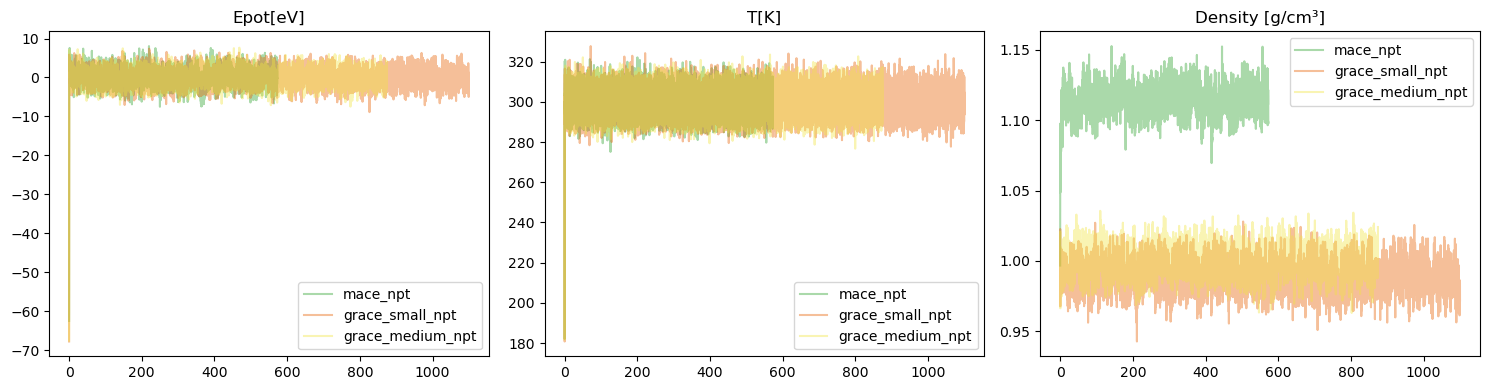

In [62]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs = axs.flatten()

# Define which color each model should use
colors = {
    'mace_npt': 'tab:green',
    'grace_small_npt': '#E66100',  # deep orange
    'grace_medium_npt': '#F0E442'  # gold/yellow
}
alpha=0.4
indices = ['Epot[eV]', 'T[K]']
for i, index in enumerate(indices):
    for name, model in data.items():
        color = colors.get(name, 'gray')  # default to gray if not defined
        if index == 'Epot[eV]':
            axs[i].plot(model['Time[ps]'], model[index] - model[index].mean(),
                        alpha=alpha, label=name, color=color)
        else:
            axs[i].plot(model['Time[ps]'], model[index],
                        alpha=alpha, label=name, color=color)
    axs[i].set_title(index)
    axs[i].legend()

for name, model in density.items():
    color = colors.get(name, 'gray')
    axs[2].plot(model['time_ps'], model['density_g_cm3'],
                alpha=alpha, label=name, color=color)
axs[2].set_title('Density [g/cm³]')
axs[2].legend()

plt.tight_layout()
plt.show()
